## MultiTemporalCrop Example

In [1]:
%pip install git+https://github.com/IBM/terratorch.git

  Cloning https://github.com/IBM/terratorch.git to c:\users\shubh\appdata\local\temp\pip-req-build-1uyl0n5u
  Resolved https://github.com/IBM/terratorch.git to commit 13b932e2560174eb6dcc93db939f9677fbd7f4dd
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/IBM/terratorch.git 'C:\Users\shubh\AppData\Local\Temp\pip-req-build-1uyl0n5u'

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import numpy as np
import torch

import terratorch
from terratorch.datamodules import MultiTemporalCropClassificationDataModule
from terratorch.tasks import SemanticSegmentationTask
from terratorch.datasets.transforms import FlattenTemporalIntoChannels, UnflattenTemporalFromChannels

import albumentations as A

import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint

c:\Users\shubh\MyStuff\GitHub\Land-Cover-Detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


If you have the data already downloaded, update the `DATASET_PATH`. Otherwise, download it with the following code. Check [here](https://huggingface.co/datasets/ibm-nasa-geospatial/multi-temporal-crop-classification) for more details on this dataset.

In [3]:
DATASET_PATH = "./data"

In [4]:
from huggingface_hub import snapshot_download

repo_id = "ibm-nasa-geospatial/multi-temporal-crop-classification"
_ = snapshot_download(repo_id=repo_id, repo_type="dataset", cache_dir="./cache", local_dir=DATASET_PATH)

2026-04-17 00:19:07,920 - INFO - HTTP Request: GET https://huggingface.co/api/datasets/ibm-nasa-geospatial/multi-temporal-crop-classification/revision/main "HTTP/1.1 200 OK"
Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 662.07it/s]


In [5]:
# Extract the tar files
import tarfile

print("Extracting training_chips.tgz...")
with tarfile.open(f"{DATASET_PATH}/training_chips.tgz", "r:gz") as tar:
    tar.extractall(path=DATASET_PATH, filter='data')
print("Finished extracting training_chips.tgz.")

print("Extracting validation_chips.tgz...")
with tarfile.open(f"{DATASET_PATH}/validation_chips.tgz", "r:gz") as tar:
    tar.extractall(path=DATASET_PATH, filter='data')
print("Finished extracting validation_chips.tgz.")

Extracting training_chips.tgz...
Finished extracting training_chips.tgz.
Extracting validation_chips.tgz...
Finished extracting validation_chips.tgz.


In [6]:
OUT_DIR = "./prithvi_out"  # where to save checkpoints and log files

BATCH_SIZE = 16
EPOCHS = 50
LR = 2.0e-4
WEIGHT_DECAY = 0.1
HEAD_DROPOUT=0.1
FREEZE_BACKBONE = True

BANDS = ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"]
NUM_FRAMES = 3

CLASS_WEIGHTS = [
    0.386375, 0.661126, 0.548184, 0.640482, 0.876862, 0.925186, 3.249462,
    1.542289, 2.175141, 2.272419, 3.062762, 3.626097, 1.198702
]

SEED = 0

#### Exploring the dataset

In [7]:
# Adding augmentations for a temporal dataset requires additional transforms
train_transforms = [
    terratorch.datasets.transforms.FlattenTemporalIntoChannels(),
    A.HorizontalFlip(),
    A.pytorch.transforms.ToTensorV2(),
    terratorch.datasets.transforms.UnflattenTemporalFromChannels(n_timesteps=NUM_FRAMES),
]

In [8]:
# This datamodule allows access to the dataset in its various splits.
data_module = MultiTemporalCropClassificationDataModule(
    data_root=DATASET_PATH,
    train_transform=train_transforms,
    expand_temporal_dimension=True,
)

In [9]:
# Checking the dataset means and stds
data_module.means, data_module.stds

([494.905781, 815.239594, 924.335066, 2968.881459, 2634.621962, 1739.579917],
 [284.925432, 357.84876, 575.566823, 896.601013, 951.900334, 921.407808])

In [10]:
# Checking train split size
data_module.setup("fit")
train_dataset = data_module.train_dataset
len(train_dataset)
sample = train_dataset[0]
print("Sample keys:", sample.keys())
print("Image shape:", sample['image'].shape)  # (T, H, W, C) = (3, 512, 512, 6)
print("Mask shape:", sample['mask'].shape)    # (H, W) = (512, 512)
print("Mask unique values (class IDs):", sample['mask'].unique())

Sample keys: dict_keys(['image', 'mask'])
Image shape: torch.Size([6, 3, 224, 224])
Mask shape: torch.Size([224, 224])
Mask unique values (class IDs): tensor([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 11, 12])


In [11]:
# Checking available bands
train_dataset.all_band_names

('BLUE', 'GREEN', 'RED', 'NIR_NARROW', 'SWIR_1', 'SWIR_2')

In [12]:
# Checking dataset classes
train_dataset.class_names

('Natural Vegetation',
 'Forest',
 'Corn',
 'Soybeans',
 'Wetlands',
 'Developed / Barren',
 'Open Water',
 'Winter Wheat',
 'Alfalfa',
 'Fallow / Idle Cropland',
 'Cotton',
 'Sorghum',
 'Other')

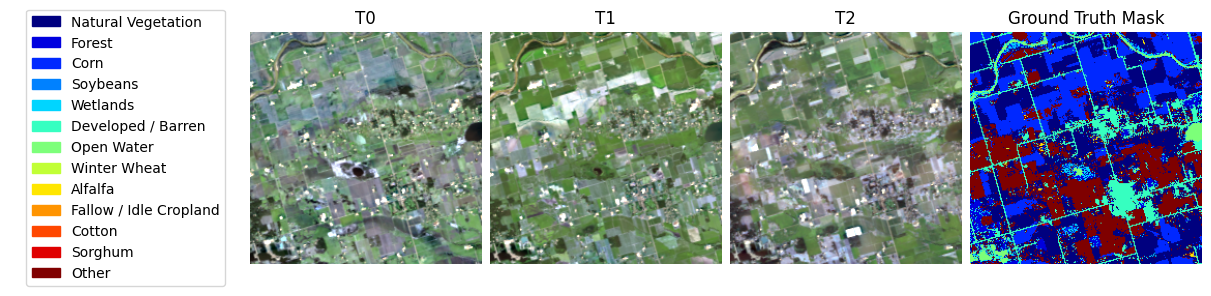

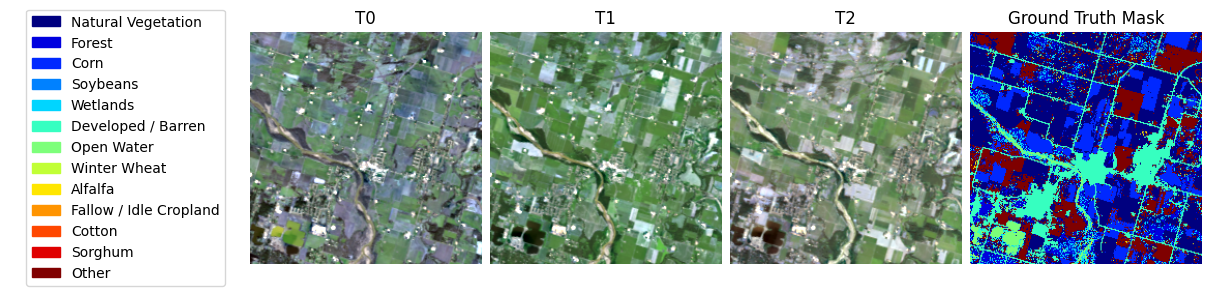

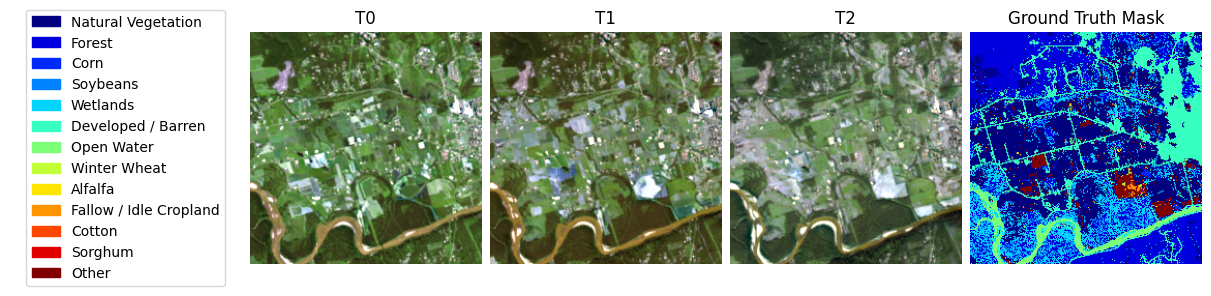

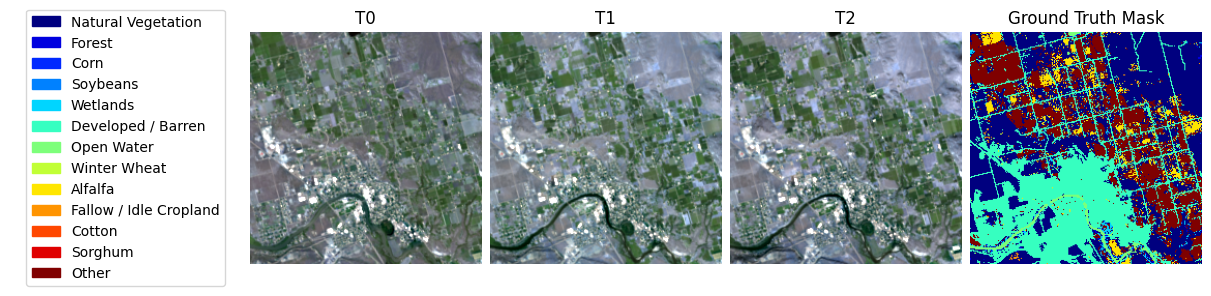

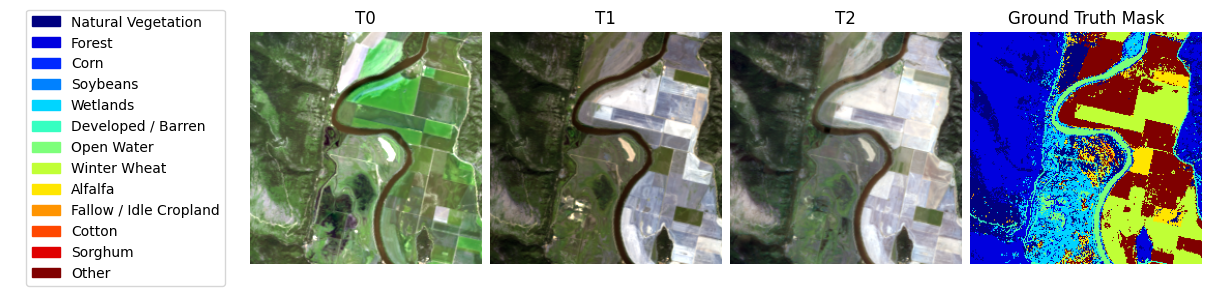

In [13]:
# Ploting a few samples
for i in range(5):
    train_dataset.plot(train_dataset[i])

In [14]:
# Checking validation split size
val_dataset = data_module.val_dataset
len(val_dataset)

771

In [15]:
# Checking test split
data_module.setup("test")
test_dataset = data_module.test_dataset
len(test_dataset)

771

#### Training setup

In [ ]:
pl.seed_everything(SEED)

# Logger
logger = TensorBoardLogger(
    save_dir=OUT_DIR,
    name="multicrop_example",
)

# Callbacks
checkpoint_callback = ModelCheckpoint(
    monitor="val/Multiclass_Jaccard_Index",
    mode="max",
    dirpath=os.path.join(OUT_DIR, "multicrop_example", "checkpoints"),
    filename="best-checkpoint-{epoch:02d}-{val_loss:.2f}",
    save_top_k=1,
)

# Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices="auto",
    precision="bf16-mixed",
    num_nodes=1,
    logger=logger,
    max_epochs=EPOCHS,
    enable_progress_bar=True,
    check_val_every_n_epoch=1,
    log_every_n_steps=10,
    enable_checkpointing=True,
    callbacks=[checkpoint_callback],
    limit_predict_batches=1,  # predict only in the first batch for generating plots
)

# DataModule
data_module = MultiTemporalCropClassificationDataModule(
    batch_size=BATCH_SIZE,
    data_root=DATASET_PATH,
    train_transform=train_transforms,
    reduce_zero_label=True,
    expand_temporal_dimension=True,
    num_workers=7,
    use_metadata=True,
)


Seed set to 0
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_predict_batches=1)` was configured so 1 batch will be used.


In [19]:
# Model

backbone_args = dict(
    backbone_pretrained=True,
    backbone="prithvi_eo_v2_300_tl", # prithvi_eo_v2_300, prithvi_eo_v2_300_tl, prithvi_eo_v2_600, prithvi_eo_v2_600_tl
    backbone_coords_encoding=["time", "location"],
    backbone_bands=BANDS,
    backbone_num_frames=NUM_FRAMES,
)

decoder_args = dict(
    decoder="UperNetDecoder",
    decoder_channels=256,
    decoder_scale_modules=True,
)

necks = [
    dict(
            name="SelectIndices",
            # indices=[2, 5, 8, 11]    # indices for prithvi_vit_100
            indices=[5, 11, 17, 23],   # indices for prithvi_eo_v2_300
            # indices=[7, 15, 23, 31]  # indices for prithvi_eo_v2_600
        ),
    dict(
            name="ReshapeTokensToImage",
            effective_time_dim=NUM_FRAMES,
        )
    ]

model_args = dict(
    **backbone_args,
    **decoder_args,
    num_classes=len(CLASS_WEIGHTS),
    head_dropout=HEAD_DROPOUT,
    necks=necks,
    rescale=True,
)


model = SemanticSegmentationTask(
    model_args=model_args,
    plot_on_val=False,
    class_weights=CLASS_WEIGHTS,
    loss="ce",
    lr=LR,
    optimizer="AdamW",
    optimizer_hparams=dict(weight_decay=WEIGHT_DECAY),
    ignore_index=-1,
    freeze_backbone=FREEZE_BACKBONE,
    freeze_decoder=True,
    model_factory="EncoderDecoderFactory",
)

2026-04-17 00:24:36,154 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL/resolve/main/Prithvi_EO_V2_300M_TL.pt "HTTP/1.1 302 Found"
2026-04-17 00:24:36,892 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-04-17 00:24:36,895 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-04-17 00:24:36,897 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-04-17 00:24:36,899 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-04-17 00:24:36,901 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-04-17 00:24:36,902 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed
c:\Users\shubh\MyStuff\GitHub\Land-Cover-Detector\venv\Lib\site-packages\terratorch\models\decoders\upernet_decoder.py:39: UserWarning: DeprecationWarning: scale_modules is deprecated and will be removed in future versions. Use LearnedInterpol

#### Training and testing the model

In [23]:
# Training, I froze both the backbone and the decoder for speed, ideally we would train decoder
trainer.fit(model, datamodule=data_module, enable_progress_bar=True)

c:\Users\shubh\MyStuff\GitHub\Land-Cover-Detector\venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  364 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 3.3 K                                                                                            
Non-trainable params: 364 M                                                                                        
Total params: 364 M                                                                                                
Total estimated model params size (MB): 1.5 K                                                                      
Modules in train mode: 652                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\shubh\MyStuff\GitHub\Land-Cover-Detector\venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\shubh\MyStuff\GitHub\Land-Cover-Detector\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21:
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\Users\shubh\MyStuff\GitHub\Land-Cover-Detector\venv\Lib\site-packages\IPython\core\interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [22]:
ckpt_path = checkpoint_callback.best_model_path

# Test results
test_results = trainer.test(model, datamodule=data_module, ckpt_path=ckpt_path)

ValueError: `.test()` found no path for the best weights: ''. Please specify a path for a checkpoint `.test(ckpt_path=PATH)`

In [ ]:
test_results

#### Plot predictions

In [ ]:
# Now we can use the model to generate predictions and visualize results
# As we set limit_predict_batches=1, only the first batch will be used

preds = trainer.predict(model, datamodule=data_module, ckpt_path=ckpt_path)

In [ ]:
# Get first batch of samples for plotting

data_loader = trainer.predict_dataloaders
batch = next(iter(data_loader))

In [ ]:
# Plot samples and respective predictions

for i in range(BATCH_SIZE):

    sample = {key: batch[key][i] for key in batch}
    sample["prediction"] = preds[0][0][i].cpu().numpy()

    data_module.predict_dataset.plot(sample)